In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis as LDA
)
from sklearn.preprocessing import StandardScaler

In [9]:
def prepare_and_plot_lda(
    df,
    embedding_col="embedding",
    class_col="condition",
    mode="2d",
    palette="viridis",
    data_type="openSMILE 0.5s",
    filters=None,
    plot_label_col=None,
):
    """
    Fit LDA and produce a 2D or 3D visualization.

    class_col:
        Labels used to fit LDA.

    plot_label_col:
        Labels used only to color the plot.
        Defaults to class_col.
    """

    data = df.copy()

    # Apply optional filtering
    if filters is not None:
        for column, allowed_values in filters.items():
            data = data[
                data[column].isin(
                    allowed_values
                )
            ].copy()

    if data.empty:
        print(
            "No rows remain after filtering."
        )
        return None, None

    # Convert stored vectors into a matrix
    X = np.vstack(
        data[embedding_col].map(
            lambda value: np.frombuffer(
                value,
                dtype=np.float32,
            ).copy()
            if isinstance(
                value,
                (bytes, bytearray, memoryview),
            )
            else np.asarray(
                value,
                dtype=np.float32,
            ).reshape(-1)
        )
    )

    y_lda = (
        data[class_col]
        .astype(str)
        .to_numpy()
    )

    number_of_classes = len(
        np.unique(y_lda)
    )

    if number_of_classes < 2:
        print(
            "LDA requires at least two classes."
        )
        return None, None

    # Use at most three components for plotting
    number_of_components = min(
        3,
        number_of_classes - 1,
    )

    # Useful for openSMILE because features
    # can have very different scales
    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    lda = LDA(
        n_components=number_of_components
    )

    transformed = lda.fit_transform(
        X_scaled,
        y_lda,
    )

    plot_label_source = (
        plot_label_col
        if plot_label_col is not None
        else class_col
    )

    if plot_label_source not in data.columns:
        raise ValueError(
            f"Column '{plot_label_source}' "
            "was not found."
        )

    plot_data = data.copy()

    plot_data["LD1"] = transformed[:, 0]

    plot_data["LD2"] = (
        transformed[:, 1]
        if number_of_components >= 2
        else np.zeros(len(plot_data))
    )

    plot_data["LD3"] = (
        transformed[:, 2]
        if number_of_components >= 3
        else np.zeros(len(plot_data))
    )

    plot_data["Plot Label"] = (
        data[plot_label_source]
        .astype(str)
        .to_numpy()
    )

    if (
        mode.lower() == "2d"
        or number_of_components < 3
    ):
        plt.figure(figsize=(11, 7))

        sns.scatterplot(
            data=plot_data,
            x="LD1",
            y="LD2",
            hue="Plot Label",
            palette=palette,
            alpha=0.5,
            s=25,
        )

        plt.title(
            f"LDA Projection of {data_type}"
        )

        plt.xlabel("LD1")
        plt.ylabel("LD2")

        plt.legend(
            title=plot_label_source,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
        )

        plt.tight_layout()
        plt.show()

    else:
        figure = plt.figure(
            figsize=(11, 8)
        )

        axis = figure.add_subplot(
            111,
            projection="3d",
        )

        labels = (
            plot_data["Plot Label"]
            .unique()
        )

        colors = sns.color_palette(
            palette,
            n_colors=len(labels),
        )

        for index, label in enumerate(labels):
            mask = (
                plot_data["Plot Label"]
                == label
            )

            axis.scatter(
                plot_data.loc[mask, "LD1"],
                plot_data.loc[mask, "LD2"],
                plot_data.loc[mask, "LD3"],
                label=label,
                alpha=0.5,
                s=20,
                color=colors[index],
            )

        axis.set_xlabel("LD1")
        axis.set_ylabel("LD2")
        axis.set_zlabel("LD3")

        axis.set_title(
            f"LDA Projection of {data_type}"
        )

        axis.legend(
            title=plot_label_source,
            bbox_to_anchor=(1.15, 1),
        )

        plt.tight_layout()
        plt.show()

    print(
        "Input features:",
        X.shape[1],
    )

    print(
        "LDA components:",
        transformed.shape[1],
    )

    print(
        "Explained discriminative variance:",
        lda.explained_variance_ratio_,
    )

    print(
        "Cumulative explained variance:",
        np.cumsum(
            lda.explained_variance_ratio_
        ),
    )

    return plot_data, lda

In [10]:
from pathlib import Path

DATASET_PATH = Path(
    "/Users/bhavaykhatri/Desktop/embeddings/openSMILE/"
    "singBAP_dataset_opensmile-compare-2016_0.5s.parquet"
)

df = pd.read_parquet(
    DATASET_PATH
)

TARGET_CLASSES = [
    "correct",
    "arched_back",
    "hunched_back",
    "sideways",
    "chest_breathing",
    "over_articulation",
    "under_articulation",
]

df = df[
    df["experience"].isin(
        [
            "intermediate",
            "professional",
        ]
    )
].copy()

df = df[
    df["condition"].isin(
        TARGET_CLASSES
    )
].copy()

df = df.reset_index(drop=True)

print(df.shape)

(28418, 13)


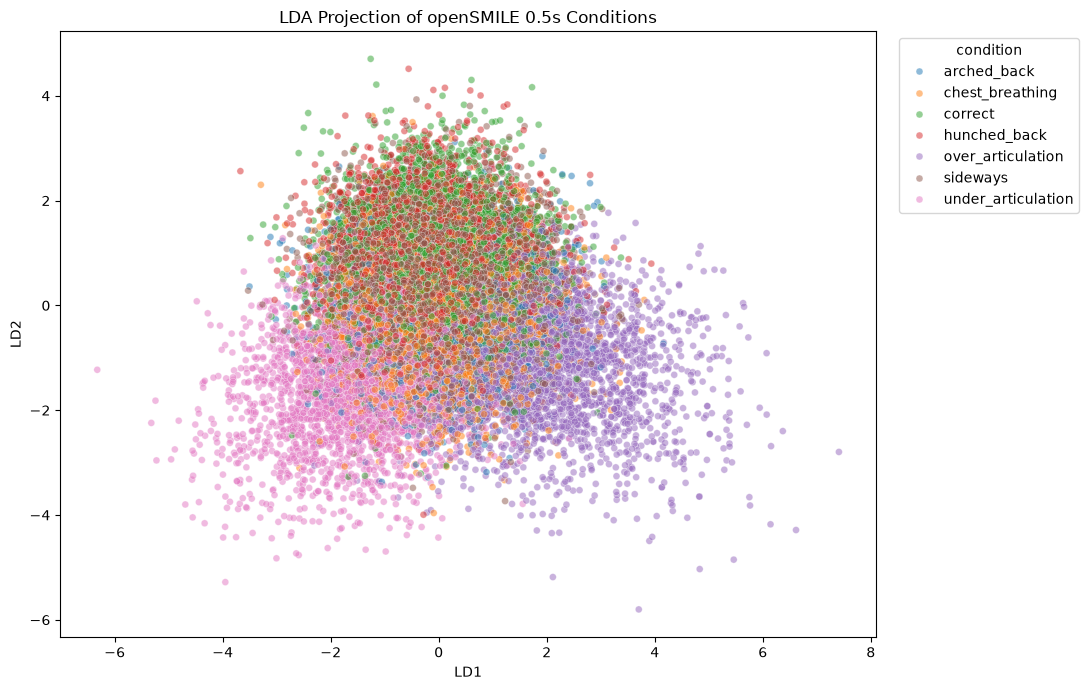

Input features: 6373
LDA components: 3
Explained discriminative variance: [0.23906374 0.2137568  0.15483847]
Cumulative explained variance: [0.23906374 0.45282054 0.607659  ]


In [11]:
condition_lda_df, condition_lda = (
    prepare_and_plot_lda(
        df=df,
        embedding_col="embedding",
        class_col="condition",
        plot_label_col="condition",
        mode="2d",
        palette="tab10",
        data_type="openSMILE 0.5s Conditions",
    )
)

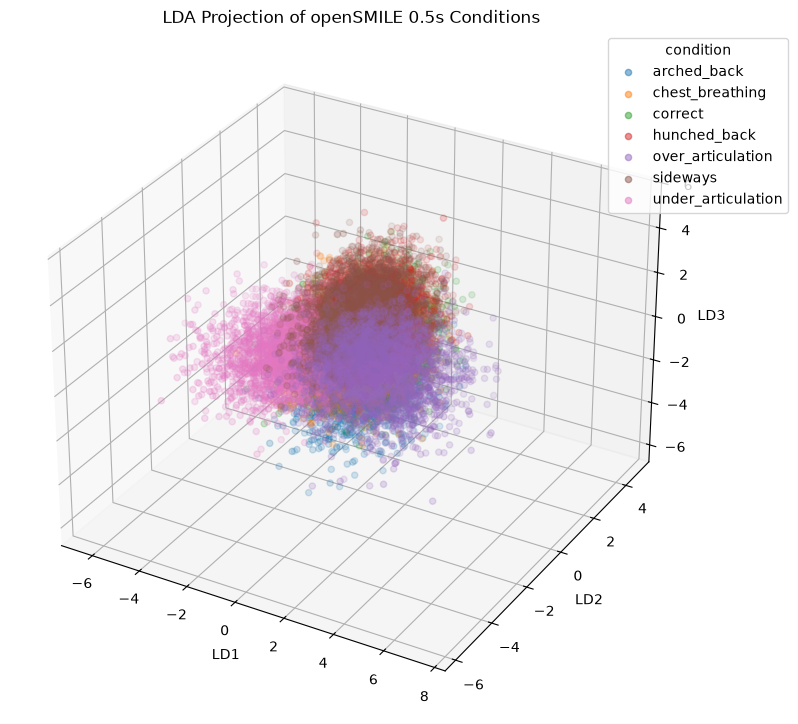

Input features: 6373
LDA components: 3
Explained discriminative variance: [0.23906374 0.2137568  0.15483847]
Cumulative explained variance: [0.23906374 0.45282054 0.607659  ]


In [12]:
condition_lda_3d_df, condition_lda_3d = (
    prepare_and_plot_lda(
        df=df,
        embedding_col="embedding",
        class_col="condition",
        plot_label_col="condition",
        mode="3d",
        palette="tab10",
        data_type="openSMILE 0.5s Conditions",
    )
)